<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

##### Import Necessary Modules:


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [4]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB

In [7]:
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65447.000000,3.374000e+04,29659.000000,29325.000000,29394.000000,29412.000000,29451.000000,29449.000000,29457.000000,29457.000000,29451.000000,29446.000000,2.343500e+04,29126.000000
mean,32714.001528,2.963841e+145,11.467143,18.580460,7.521884,10.060515,24.342405,22.964440,20.277477,16.168883,10.955341,9.953610,8.615529e+04,6.935041
std,18893.063225,5.444117e+147,9.168610,25.966005,18.422399,21.833543,27.089272,27.017612,26.107934,24.844789,22.905963,21.775359,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16352.500000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32714.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.000000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49075.500000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.000000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


In [8]:
df.describe(include='object')

/tmp/ipykernel_1343/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')

,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,...,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,SurveyLength,SurveyEase
count,65447,65447,65447,54812,65447,54472,60794,60498,49245,40902,...,27710,28911,28844,28251,27764,28491,28807,28858,56190,56246
unique,5,8,110,3,1,118,8,418,10853,113,...,5,5,5,954,514,3,9,15,3,3
top,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,API document(s) and/or SDK document(s);User gu...,...,1-2 times a week,30-60 minutes a day,15-30 minutes a day,None of these,None of these,Hybrid (on-prem and cloud),Traditional public search engine,Software Development,Appropriate in length,Easy
freq,50212,23911,39046,23015,65447,9995,24943,3676,603,6948,...,14426,10951,9341,2364,2834,13230,15813,11918,38771,30076


The dataset contains 100 categorical columns with varying levels of completeness. Some columns such as MainBranch are fully populated, while others like TechDoc and Frustration have many missing values. The most frequent responses indicate that the majority of participants are professional developers employed full-time. This highlights the survey-based and self-reported nature of the dataset.

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [9]:
missing_values = df.isnull().sum()
print(missing_values)

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64

In [11]:
missing_values.sort_values(ascending=False).head(20)

AINextMuch less integrated       64299
AINextLess integrated            63092
AINextNo change                  52947
AINextMuch more integrated       52008
EmbeddedAdmired                  48711
EmbeddedWantToWorkWith           47844
EmbeddedHaveWorkedWith           43229
ConvertedCompYearly              42012
AIToolNot interested in Using    41032
AINextMore integrated            41018
Knowledge_9                      37811
Frequency_3                      37737
Knowledge_8                      37688
ProfessionalTech                 37683
Knowledge_7                      37668
Knowledge_6                      37582
Knowledge_5                      37566
Knowledge_2                      37425
Knowledge_4                      37416
Knowledge_3                      37351
dtype: int64

The dataset contains a mix of fully populated demographic columns and highly incomplete technical/survey-specific columns. Missing values are especially concentrated in optional questions related to AI tools, knowledge areas, and compensation.

##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



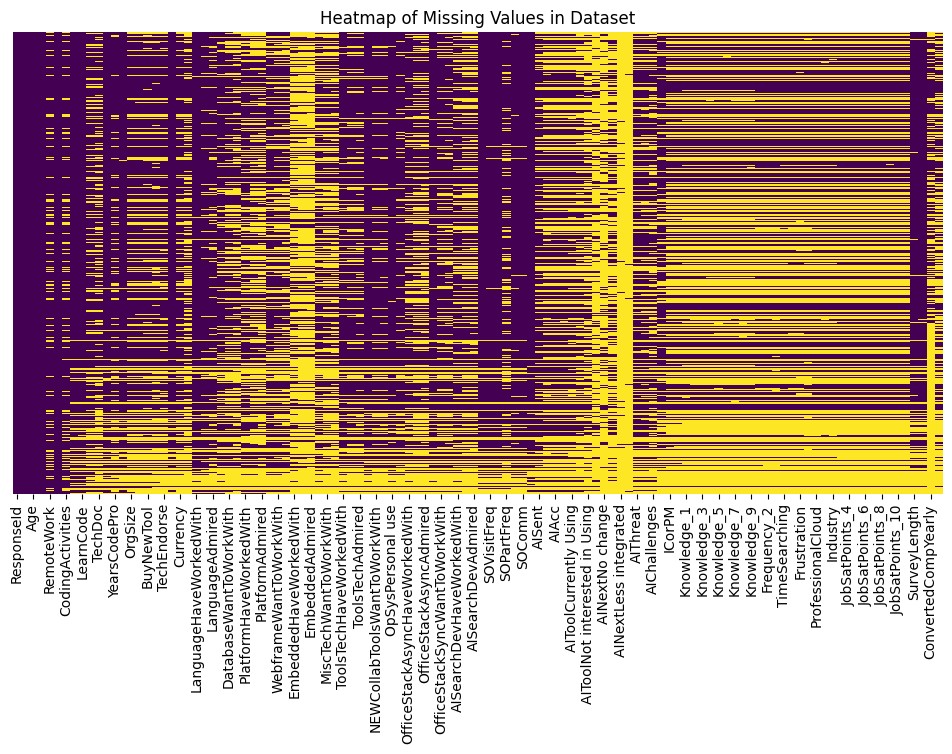

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size for readability
plt.figure(figsize=(12, 6))

# Create heatmap of missing values
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

# Add title
plt.title("Heatmap of Missing Values in Dataset")

plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [13]:
# Employment column
df['Employment'].isnull().sum()

np.int64(0)

### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [16]:
# Most Frequent Value in a Column
df['Employment'].mode()

0    Employed, full-time
Name: Employment, dtype: str

##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [17]:
most_frequent_employment = df['Employment'].mode()[0]
df['Employment'] = df['Employment'].fillna(most_frequent_employment)
df['Employment'].isnull().sum()

np.int64(0)

The Employment column was checked for missing values and was found to have none. However, the imputation step was demonstrated to show how missing categorical values would be handled using the most frequent value (mode), which is a standard data cleaning technique.

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


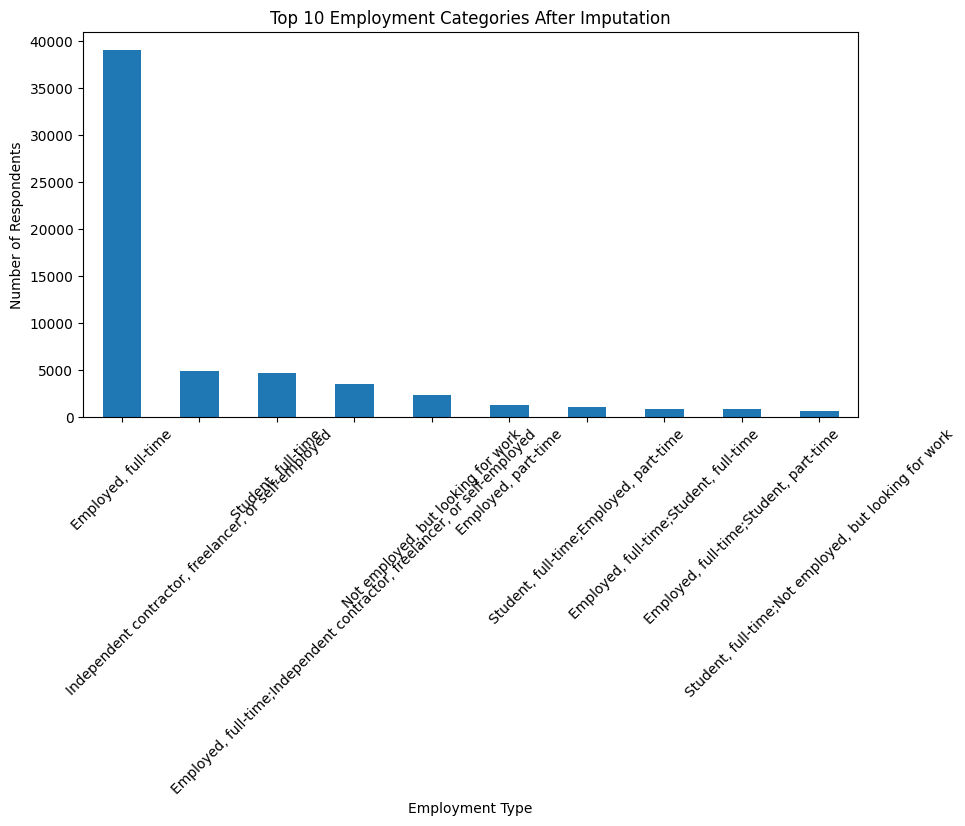

In [18]:
import matplotlib.pyplot as plt

# Count values in Employment column
employment_counts = df['Employment'].value_counts()

# Plot
plt.figure(figsize=(10,5))
employment_counts.head(10).plot(kind='bar')

plt.title("Top 10 Employment Categories After Imputation")
plt.xlabel("Employment Type")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.show()

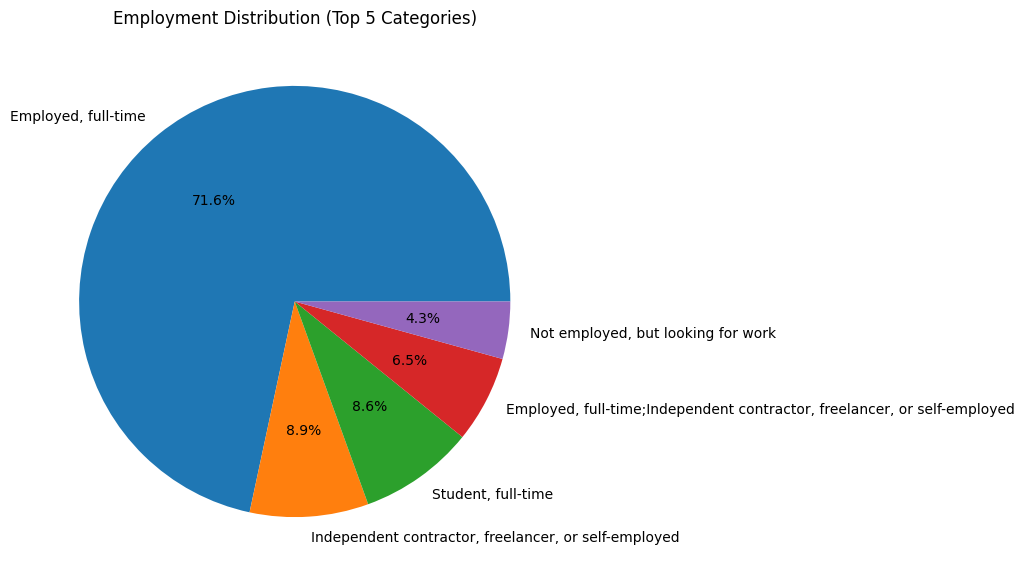

In [19]:
plt.figure(figsize=(7,7))
df['Employment'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%')

plt.title("Employment Distribution (Top 5 Categories)")
plt.ylabel("")
plt.show()

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
